In [55]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [56]:
df = pd.read_csv("../Data/processed/ONE_SENSOR_TRAFIC_DATA_ONLY_ALL_YEARS.csv")

In [57]:
df = df.sort_values("timestamp").reset_index(drop=True)

split_idx = int(len(df) * 0.7)

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

print("Train:", train_df["timestamp"].min(), "→", train_df["timestamp"].max())
print("Test:", test_df["timestamp"].min(), "→", test_df["timestamp"].max())
print(train_df.shape, test_df.shape)

Train: 2024-01-01 00:30:00 → 2024-09-13 02:55:00
Test: 2024-09-13 02:55:00 → 2024-12-31 23:15:00
(220644, 60) (94563, 60)


In [58]:
df.columns

Index(['flow', 'occupancy', 'speed', 'timestamp', 'sensor_index', 'sensor_id',
       'date', 'is_congested', 'congestion_30min', 'congestion_60min',
       'congestion_90min', 'congestion_120min', 'hour', 'minute',
       'day_of_week', 'day', 'is_weekend', 'month', 'hour_sin', 'hour_cos',
       'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'speed_lag_5m',
       'flow_lag_5m', 'occupancy_lag_5m', 'speed_lag_15m', 'flow_lag_15m',
       'occupancy_lag_15m', 'speed_lag_30m', 'flow_lag_30m',
       'occupancy_lag_30m', 'speed_lag_60m', 'flow_lag_60m',
       'occupancy_lag_60m', 'speed_lag_90m', 'flow_lag_90m',
       'occupancy_lag_90m', 'speed_roll_mean_15m', 'speed_roll_std_15m',
       'flow_roll_mean_15m', 'occupancy_roll_mean_15m', 'speed_roll_mean_30m',
       'speed_roll_std_30m', 'flow_roll_mean_30m', 'occupancy_roll_mean_30m',
       'speed_roll_mean_60m', 'speed_roll_std_60m', 'flow_roll_mean_60m',
       'occupancy_roll_mean_60m', 'speed_roll_mean_90m', 'speed_roll_std_90

In [92]:
df["sensor_id"].unique()

array([819086])

In [59]:
target_cols = [
    "congestion_30min",
    "congestion_60min",
    "congestion_90min",
    "congestion_120min"
]

feature_cols = ['flow', 'occupancy', 'speed', 'is_congested', 'hour', 'minute',
       'day_of_week', 'day', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin',
       'dow_cos','month', 'month_cos','month_sin', 'speed_lag_5m', 'flow_lag_5m', 'occupancy_lag_5m',
       'speed_lag_15m', 'flow_lag_15m', 'occupancy_lag_15m', 'speed_lag_30m',
       'flow_lag_30m', 'occupancy_lag_30m', 'speed_lag_60m', 'flow_lag_60m',
       'occupancy_lag_60m', 'speed_lag_90m', 'flow_lag_90m',
       'occupancy_lag_90m', 'speed_roll_mean_15m', 'speed_roll_std_15m',
       'flow_roll_mean_15m', 'occupancy_roll_mean_15m', 'speed_roll_mean_30m',
       'speed_roll_std_30m', 'flow_roll_mean_30m', 'occupancy_roll_mean_30m',
       'speed_roll_mean_60m', 'speed_roll_std_60m', 'flow_roll_mean_60m',
       'occupancy_roll_mean_60m', 'speed_roll_mean_90m', 'speed_roll_std_90m',
       'flow_roll_mean_90m', 'occupancy_roll_mean_90m', 'speed_diff_5m',
       'speed_diff_15m', 'speed_diff_30m', 'occupancy_diff_5m',
       'occupancy_diff_15m']

In [60]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

baseline_results = []

for target in target_cols:
    y_true = test_df[target]
    
    # Baseline: asumo que el futuro será igual al estado actual
    y_pred = test_df["is_congested"]
    
    baseline_results.append({
        "target": target,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "positive_rate_true": y_true.mean(),
        "positive_rate_pred": y_pred.mean()
    })

baseline_results_df = pd.DataFrame(baseline_results)

baseline_results_df

,target,accuracy,precision,recall,f1,positive_rate_true,positive_rate_pred
0,congestion_30min,0.806415,0.701312,0.701312,0.701312,0.324059,0.324059
1,congestion_60min,0.791314,0.678012,0.678012,0.678012,0.324059,0.324059
2,congestion_90min,0.787909,0.672758,0.672758,0.672758,0.324059,0.324059
3,congestion_120min,0.779935,0.660456,0.660456,0.660456,0.324059,0.324059


In [61]:
target = "congestion_30min"

y_true = test_df[target]
y_pred = test_df["is_congested"]

cm = confusion_matrix(y_true, y_pred)

cm

array([[54766,  9153],
       [ 9153, 21491]])

In [62]:
early_test_df = test_df[test_df["is_congested"] == 0].copy()

early_warning_results = []

for target in target_cols:
    y_true = early_test_df[target]
    
    # Persistence baseline en casos no congestionados ahora siempre predice 0
    y_pred = early_test_df["is_congested"]
    
    early_warning_results.append({
        "target": target,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "positive_rate_true": y_true.mean(),
        "n_rows": len(early_test_df)
    })

early_warning_results_df = pd.DataFrame(early_warning_results)

early_warning_results_df

,target,accuracy,precision,recall,f1,positive_rate_true,n_rows
0,congestion_30min,0.856803,0.0,0.0,0.0,0.143197,63919
1,congestion_60min,0.845633,0.0,0.0,0.0,0.154367,63919
2,congestion_90min,0.843114,0.0,0.0,0.0,0.156886,63919
3,congestion_120min,0.837216,0.0,0.0,0.0,0.162784,63919


El baseline de persistencia no sirve para detectar congestión antes de que ocurra. Si el tráfico todavía no está congestionado, siempre predice que seguirá normal. Por eso tiene recall 0 en los casos de early warning.

In [63]:
train_df[feature_cols].isna().sum()[train_df[feature_cols].isna().sum() > 0]

Series([], dtype: int64)

In [64]:
train_df["occupancy_lag_90m"]

0         0.0101
1         0.0120
2         0.0125
3         0.0068
4         0.0084
           ...  
220639    0.0333
220640    0.0367
220641    0.0273
220642    0.0321
220643    0.0341
Name: occupancy_lag_90m, Length: 220644, dtype: float64

In [65]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logreg_models = {}
logreg_results = []

for target in target_cols:
    X_train = train_df[feature_cols]
    y_train = train_df[target]

    X_test = test_df[feature_cols]
    y_test = test_df[target]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    logreg_models[target] = model

    logreg_results.append({
        "target": target,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "positive_rate_true": y_test.mean(),
        "positive_rate_pred": y_pred.mean()
    })

logreg_results_df = pd.DataFrame(logreg_results)

logreg_results_df

,target,accuracy,precision,recall,f1,roc_auc,positive_rate_true,positive_rate_pred
0,congestion_30min,0.820501,0.655468,0.940380,0.772491,0.917245,0.324059,0.464918
1,congestion_60min,0.813563,0.646713,0.936007,0.764921,0.910398,0.324059,0.469021
2,congestion_90min,0.808762,0.641403,0.929578,0.759060,0.904435,0.324059,0.469655
3,congestion_120min,0.804934,0.636406,0.928567,0.755215,0.899532,0.324059,0.472828


In [66]:
early_test_df = test_df[test_df["is_congested"] == 0].copy()

logreg_early_results = []

for target in target_cols:
    model = logreg_models[target]

    X_early = early_test_df[feature_cols]
    y_early = early_test_df[target]

    y_pred = model.predict(X_early)
    y_proba = model.predict_proba(X_early)[:, 1]

    logreg_early_results.append({
        "target": target,
        "accuracy": accuracy_score(y_early, y_pred),
        "precision": precision_score(y_early, y_pred, zero_division=0),
        "recall": recall_score(y_early, y_pred, zero_division=0),
        "f1": f1_score(y_early, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_early, y_proba),
        "positive_rate_true": y_early.mean(),
        "positive_rate_pred": y_pred.mean(),
        "n_rows": len(early_test_df)
    })

logreg_early_results_df = pd.DataFrame(logreg_early_results)

logreg_early_results_df

,target,accuracy,precision,recall,f1,roc_auc,positive_rate_true,positive_rate_pred,n_rows
0,congestion_30min,0.869913,0.528841,0.839397,0.648875,0.933382,0.143197,0.227288,63919
1,congestion_60min,0.867473,0.545544,0.847370,0.663756,0.931218,0.154367,0.239772,63919
2,congestion_90min,0.861121,0.537079,0.831272,0.652550,0.926129,0.156886,0.242823,63919
3,congestion_120min,0.858289,0.541997,0.835368,0.657439,0.922730,0.162784,0.250896,63919


In [67]:
comparison = baseline_results_df.merge(
    logreg_results_df,
    on="target",
    suffixes=("_baseline", "_logreg")
)

comparison[
    [
        "target",
        "accuracy_baseline",
        "accuracy_logreg",
        "precision_baseline",
        "precision_logreg",
        "recall_baseline",
        "recall_logreg",
        "f1_baseline",
        "f1_logreg",
        "roc_auc"
    ]
]

,target,accuracy_baseline,accuracy_logreg,precision_baseline,precision_logreg,recall_baseline,recall_logreg,f1_baseline,f1_logreg,roc_auc
0,congestion_30min,0.806415,0.820501,0.701312,0.655468,0.701312,0.940380,0.701312,0.772491,0.917245
1,congestion_60min,0.791314,0.813563,0.678012,0.646713,0.678012,0.936007,0.678012,0.764921,0.910398
2,congestion_90min,0.787909,0.808762,0.672758,0.641403,0.672758,0.929578,0.672758,0.759060,0.904435
3,congestion_120min,0.779935,0.804934,0.660456,0.636406,0.660456,0.928567,0.660456,0.755215,0.899532


In [68]:
early_test_df = test_df[test_df["is_congested"] == 0].copy()

logreg_early_results = []

for target in target_cols:
    model = logreg_models[target]

    X_early = early_test_df[feature_cols]
    y_early = early_test_df[target]

    y_pred = model.predict(X_early)
    y_proba = model.predict_proba(X_early)[:, 1]

    logreg_early_results.append({
        "target": target,
        "accuracy": accuracy_score(y_early, y_pred),
        "precision": precision_score(y_early, y_pred, zero_division=0),
        "recall": recall_score(y_early, y_pred, zero_division=0),
        "f1": f1_score(y_early, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_early, y_proba),
        "positive_rate_true": y_early.mean(),
        "positive_rate_pred": y_pred.mean(),
        "n_rows": len(early_test_df)
    })

logreg_early_results_df = pd.DataFrame(logreg_early_results)

logreg_early_results_df

,target,accuracy,precision,recall,f1,roc_auc,positive_rate_true,positive_rate_pred,n_rows
0,congestion_30min,0.869913,0.528841,0.839397,0.648875,0.933382,0.143197,0.227288,63919
1,congestion_60min,0.867473,0.545544,0.847370,0.663756,0.931218,0.154367,0.239772,63919
2,congestion_90min,0.861121,0.537079,0.831272,0.652550,0.926129,0.156886,0.242823,63919
3,congestion_120min,0.858289,0.541997,0.835368,0.657439,0.922730,0.162784,0.250896,63919


In [69]:
threshold_results = []

early_test_df = test_df[test_df["is_congested"] == 0].copy()

thresholds = np.arange(0.10, 1, 0.05)

for target in target_cols:
    model = logreg_models[target]

    X_early = early_test_df[feature_cols]
    y_true = early_test_df[target]
    y_proba = model.predict_proba(X_early)[:, 1]

    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)

        threshold_results.append({
            "target": target,
            "threshold": threshold,
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "positive_rate_pred": y_pred.mean(),
            "positive_rate_true": y_true.mean()
        })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df.head()

,target,threshold,accuracy,precision,recall,f1,positive_rate_pred,positive_rate_true
0,congestion_30min,0.10,0.777687,0.391074,0.991806,0.560959,0.363163,0.143197
1,congestion_30min,0.15,0.803877,0.420836,0.982410,0.589253,0.334282,0.143197
2,congestion_30min,0.20,0.820726,0.442545,0.970283,0.607851,0.313960,0.143197
3,congestion_30min,0.25,0.833023,0.459945,0.953458,0.620543,0.296844,0.143197
4,congestion_30min,0.30,0.842253,0.474190,0.933355,0.628879,0.281857,0.143197


In [70]:
best_f1_thresholds = (
    threshold_results_df
    .sort_values(["target", "f1"], ascending=[True, False])
    .groupby("target")
    .head(1)
)

best_f1_thresholds

,target,threshold,accuracy,precision,recall,f1,positive_rate_pred,positive_rate_true
62,congestion_120min,0.5,0.858289,0.541997,0.835368,0.657439,0.250896,0.162784
8,congestion_30min,0.5,0.869913,0.528841,0.839397,0.648875,0.227288,0.143197
26,congestion_60min,0.5,0.867473,0.545544,0.847370,0.663756,0.239772,0.154367
44,congestion_90min,0.5,0.861121,0.537079,0.831272,0.652550,0.242823,0.156886


In [71]:
high_recall_thresholds = (
    threshold_results_df[threshold_results_df["recall"] >= 0.85]
    .sort_values(["target", "precision"], ascending=[True, False])
    .groupby("target")
    .head(1)
)

high_recall_thresholds

,target,threshold,accuracy,precision,recall,f1,positive_rate_pred,positive_rate_true
61,congestion_120min,0.45,0.851390,0.526525,0.864200,0.654368,0.267182,0.162784
7,congestion_30min,0.45,0.863749,0.514382,0.867475,0.645817,0.241493,0.143197
25,congestion_60min,0.45,0.861872,0.532061,0.872910,0.661140,0.253258,0.154367
43,congestion_90min,0.45,0.854973,0.523003,0.859294,0.650241,0.257764,0.156886


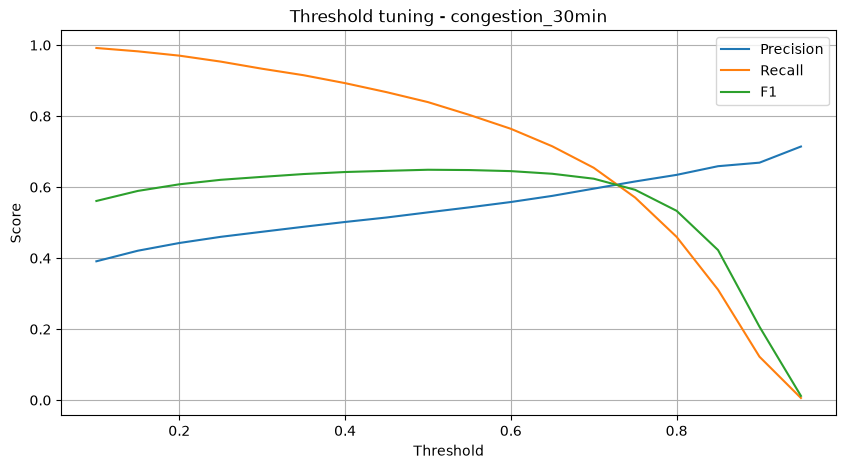

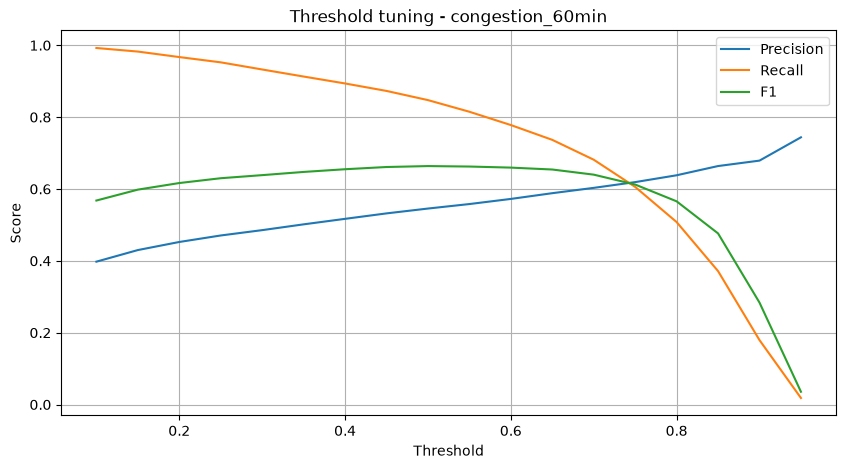

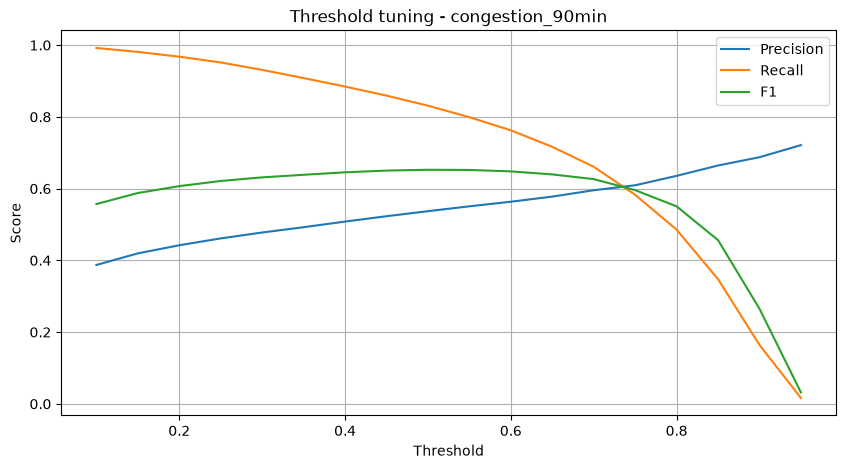

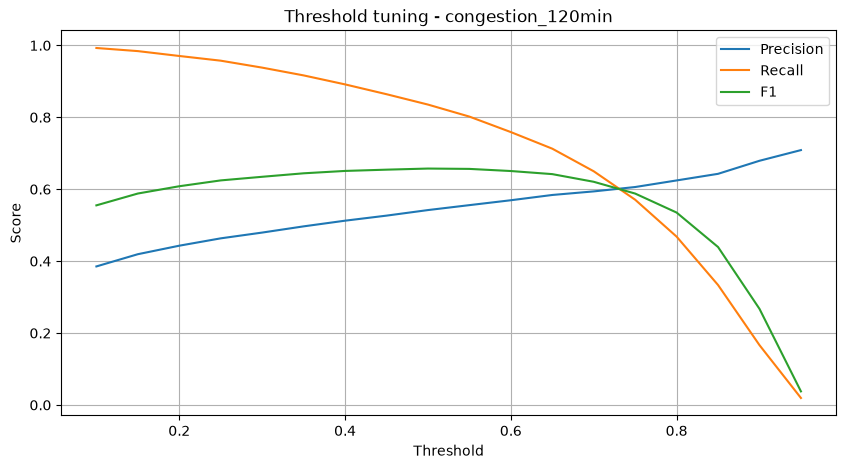

In [72]:
import matplotlib.pyplot as plt

for target in target_cols:
    temp = threshold_results_df[threshold_results_df["target"] == target]

    plt.figure(figsize=(10, 5))
    plt.plot(temp["threshold"], temp["precision"], label="Precision")
    plt.plot(temp["threshold"], temp["recall"], label="Recall")
    plt.plot(temp["threshold"], temp["f1"], label="F1")

    plt.title(f"Threshold tuning - {target}")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True)
    plt.show()

In [73]:
OPERATIONAL_THRESHOLD = 0.4

tuned_results = []

for target in target_cols:
    model = logreg_models[target]

    X_test = test_df[feature_cols]
    y_true = test_df[target]

    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= OPERATIONAL_THRESHOLD).astype(int)

    tuned_results.append({
        "target": target,
        "threshold": OPERATIONAL_THRESHOLD,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "positive_rate_true": y_true.mean(),
        "positive_rate_pred": y_pred.mean()
    })

tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df

,target,threshold,accuracy,precision,recall,f1,positive_rate_true,positive_rate_pred
0,congestion_30min,0.4,0.810433,0.637581,0.961656,0.766783,0.324059,0.488775
1,congestion_60min,0.4,0.802650,0.628177,0.958132,0.758839,0.324059,0.494274
2,congestion_90min,0.4,0.797162,0.621866,0.954412,0.753061,0.324059,0.497351
3,congestion_120min,0.4,0.792339,0.615924,0.954216,0.748627,0.324059,0.502046


In [74]:
early_test_df = test_df[test_df["is_congested"] == 0].copy()

tuned_early_results = []

for target in target_cols:
    model = logreg_models[target]

    X_early = early_test_df[feature_cols]
    y_true = early_test_df[target]

    y_proba = model.predict_proba(X_early)[:, 1]
    y_pred = (y_proba >= OPERATIONAL_THRESHOLD).astype(int)

    tuned_early_results.append({
        "target": target,
        "threshold": OPERATIONAL_THRESHOLD,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "positive_rate_true": y_true.mean(),
        "positive_rate_pred": y_pred.mean(),
        "n_rows": len(early_test_df)
    })

tuned_early_results_df = pd.DataFrame(tuned_early_results)

tuned_early_results_df

,target,threshold,accuracy,precision,recall,f1,positive_rate_true,positive_rate_pred,n_rows
0,congestion_30min,0.4,0.857711,0.501781,0.892822,0.642478,0.143197,0.254791,63919
1,congestion_60min,0.4,0.854644,0.516882,0.893686,0.654956,0.154367,0.266900,63919
2,congestion_90min,0.4,0.847541,0.508106,0.884523,0.645443,0.156886,0.273111,63919
3,congestion_120min,0.4,0.844287,0.512486,0.891494,0.650833,0.162784,0.283171,63919


In [75]:
df_alerts = test_df.copy()

for target in target_cols:
    horizon = target.replace("congestion_", "")

    model = logreg_models[target]

    proba_col = f"proba_{horizon}"
    alert_col = f"alert_{horizon}"

    df_alerts[proba_col] = model.predict_proba(
        df_alerts[feature_cols]
    )[:, 1]

    df_alerts[alert_col] = (
        df_alerts[proba_col] >= OPERATIONAL_THRESHOLD
    ).astype(int)

df_alerts.head()

,flow,occupancy,speed,timestamp,sensor_index,sensor_id,date,is_congested,congestion_30min,congestion_60min,...,occupancy_diff_5m,occupancy_diff_15m,proba_30min,alert_30min,proba_60min,alert_60min,proba_90min,alert_90min,proba_120min,alert_120min
220644,95.0,0.0365,60.800000,2024-09-13 02:55:00,14698,819086,2024-09-13,0,0.0,0.0,...,0.0046,0.0071,0.011624,0,0.014869,0,0.017079,0,0.021113,0
220645,76.0,0.0304,70.300003,2024-09-13 02:55:00,14698,819086,2024-09-13,0,0.0,0.0,...,-0.0061,-0.0047,0.013102,0,0.016347,0,0.018077,0,0.021587,0
220646,103.0,0.0362,64.800000,2024-09-13 03:00:00,14698,819086,2024-09-13,0,0.0,0.0,...,0.0022,0.0058,0.014906,0,0.021169,0,0.027381,0,0.031613,0
220647,98.0,0.0340,69.099998,2024-09-13 03:00:00,14698,819086,2024-09-13,0,0.0,0.0,...,0.0017,-0.0025,0.014613,0,0.021806,0,0.028170,0,0.031647,0
220648,94.0,0.0323,62.400000,2024-09-13 03:00:00,14698,819086,2024-09-13,0,0.0,0.0,...,0.0019,0.0004,0.014357,0,0.020999,0,0.028127,0,0.033415,0


In [76]:
OPERATIONAL_THRESHOLD = 0.30

df_alerts = test_df.copy()
df_alerts["timestamp"] = pd.to_datetime(df_alerts["timestamp"])

for target in target_cols:
    horizon = target.replace("congestion_", "")

    model = logreg_models[target]

    proba_col = f"proba_{horizon}"
    alert_col = f"alert_{horizon}"

    df_alerts[proba_col] = model.predict_proba(
        df_alerts[feature_cols]
    )[:, 1]

    df_alerts[alert_col] = (
        df_alerts[proba_col] >= OPERATIONAL_THRESHOLD
    ).astype(int)

df_alerts.head()

,flow,occupancy,speed,timestamp,sensor_index,sensor_id,date,is_congested,congestion_30min,congestion_60min,...,occupancy_diff_5m,occupancy_diff_15m,proba_30min,alert_30min,proba_60min,alert_60min,proba_90min,alert_90min,proba_120min,alert_120min
220644,95.0,0.0365,60.800000,2024-09-13 02:55:00,14698,819086,2024-09-13,0,0.0,0.0,...,0.0046,0.0071,0.011624,0,0.014869,0,0.017079,0,0.021113,0
220645,76.0,0.0304,70.300003,2024-09-13 02:55:00,14698,819086,2024-09-13,0,0.0,0.0,...,-0.0061,-0.0047,0.013102,0,0.016347,0,0.018077,0,0.021587,0
220646,103.0,0.0362,64.800000,2024-09-13 03:00:00,14698,819086,2024-09-13,0,0.0,0.0,...,0.0022,0.0058,0.014906,0,0.021169,0,0.027381,0,0.031613,0
220647,98.0,0.0340,69.099998,2024-09-13 03:00:00,14698,819086,2024-09-13,0,0.0,0.0,...,0.0017,-0.0025,0.014613,0,0.021806,0,0.028170,0,0.031647,0
220648,94.0,0.0323,62.400000,2024-09-13 03:00:00,14698,819086,2024-09-13,0,0.0,0.0,...,0.0019,0.0004,0.014357,0,0.020999,0,0.028127,0,0.033415,0


In [77]:

selected_day = pd.Timestamp("2024-04-13")


day_alerts = df_alerts[
    (df_alerts["timestamp"] >= selected_day) &
    (df_alerts["timestamp"] < selected_day + pd.Timedelta(days=1))
].copy()

print(day_alerts.shape)
print(day_alerts["timestamp"].min())
print(day_alerts["timestamp"].max())

(0, 68)
NaT
NaT


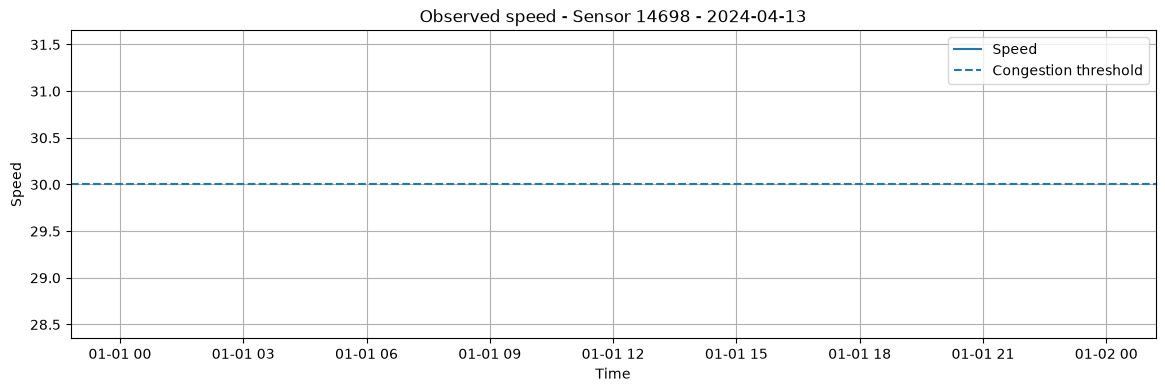

In [78]:

plt.figure(figsize=(14, 4))

plt.plot(day_alerts["timestamp"], day_alerts["speed"], label="Speed")
plt.axhline(30, linestyle="--", label="Congestion threshold")

plt.title(f"Observed speed - Sensor {df['sensor_index'].iloc[0]} - {selected_day.date()}")
plt.xlabel("Time")
plt.ylabel("Speed")
plt.legend()
plt.grid(True)

plt.show()

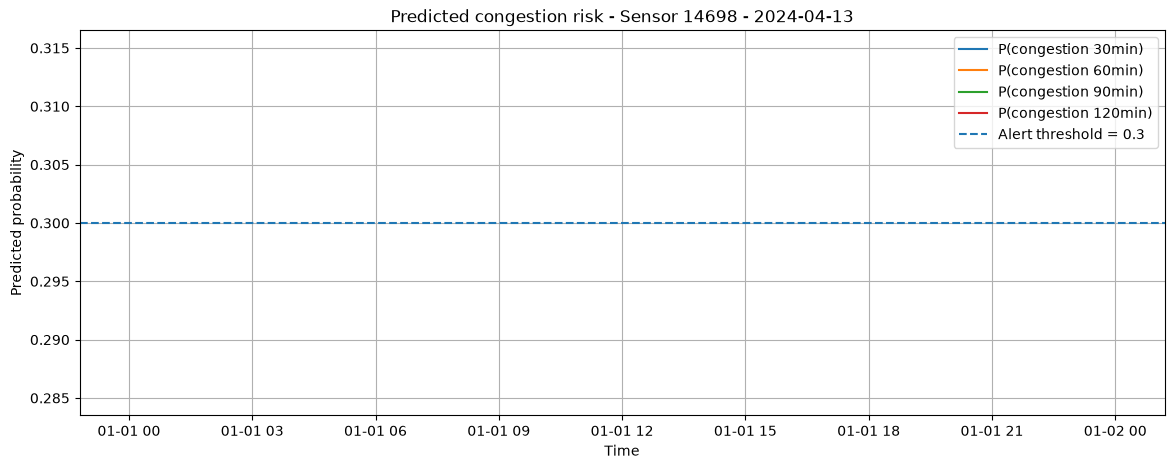

In [79]:
plt.figure(figsize=(14, 5))

plt.plot(day_alerts["timestamp"], day_alerts["proba_30min"], label="P(congestion 30min)")
plt.plot(day_alerts["timestamp"], day_alerts["proba_60min"], label="P(congestion 60min)")
plt.plot(day_alerts["timestamp"], day_alerts["proba_90min"], label="P(congestion 90min)")
plt.plot(day_alerts["timestamp"], day_alerts["proba_120min"], label="P(congestion 120min)")

plt.axhline(OPERATIONAL_THRESHOLD, linestyle="--", label=f"Alert threshold = {OPERATIONAL_THRESHOLD}")

plt.title(f"Predicted congestion risk - Sensor {df['sensor_index'].iloc[0]} - {selected_day.date()}")
plt.xlabel("Time")
plt.ylabel("Predicted probability")
plt.legend()
plt.grid(True)

plt.show()

In [80]:
from xgboost import XGBClassifier

xgb_models = {}
xgb_results = []

for target in target_cols:
    X_train = train_df[feature_cols]
    y_train = train_df[target]

    X_test = test_df[feature_cols]
    y_test = test_df[target]

    model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    xgb_models[target] = model

    xgb_results.append({
        "target": target,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "positive_rate_true": y_test.mean(),
        "positive_rate_pred": y_pred.mean()
    })

xgb_results_df = pd.DataFrame(xgb_results)

xgb_results_df

,target,accuracy,precision,recall,f1,roc_auc,positive_rate_true,positive_rate_pred
0,congestion_30min,0.837674,0.722867,0.809392,0.763686,0.921361,0.324059,0.362848
1,congestion_60min,0.829183,0.723938,0.764358,0.743599,0.915149,0.324059,0.342153
2,congestion_90min,0.822817,0.716279,0.750522,0.733001,0.910412,0.324059,0.339551
3,congestion_120min,0.817170,0.714359,0.726178,0.720220,0.905959,0.324059,0.329421


In [81]:
model_comparison = logreg_results_df.merge(
    xgb_results_df,
    on="target",
    suffixes=("_logreg", "_xgb")
)

model_comparison[
    [
        "target",
        "accuracy_logreg",
        "accuracy_xgb",
        "precision_logreg",
        "precision_xgb",
        "recall_logreg",
        "recall_xgb",
        "f1_logreg",
        "f1_xgb",
        "roc_auc_logreg",
        "roc_auc_xgb"
    ]
]

,target,accuracy_logreg,accuracy_xgb,precision_logreg,precision_xgb,recall_logreg,recall_xgb,f1_logreg,f1_xgb,roc_auc_logreg,roc_auc_xgb
0,congestion_30min,0.820501,0.837674,0.655468,0.722867,0.940380,0.809392,0.772491,0.763686,0.917245,0.921361
1,congestion_60min,0.813563,0.829183,0.646713,0.723938,0.936007,0.764358,0.764921,0.743599,0.910398,0.915149
2,congestion_90min,0.808762,0.822817,0.641403,0.716279,0.929578,0.750522,0.759060,0.733001,0.904435,0.910412
3,congestion_120min,0.804934,0.817170,0.636406,0.714359,0.928567,0.726178,0.755215,0.720220,0.899532,0.905959


In [82]:
early_test_df = test_df[test_df["is_congested"] == 0].copy()

xgb_early_results = []

for target in target_cols:
    model = xgb_models[target]

    X_early = early_test_df[feature_cols]
    y_early = early_test_df[target]

    y_pred = model.predict(X_early)
    y_proba = model.predict_proba(X_early)[:, 1]

    xgb_early_results.append({
        "target": target,
        "accuracy": accuracy_score(y_early, y_pred),
        "precision": precision_score(y_early, y_pred, zero_division=0),
        "recall": recall_score(y_early, y_pred, zero_division=0),
        "f1": f1_score(y_early, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_early, y_proba),
        "positive_rate_true": y_early.mean(),
        "positive_rate_pred": y_pred.mean(),
        "n_rows": len(early_test_df)
    })

xgb_early_results_df = pd.DataFrame(xgb_early_results)

xgb_early_results_df

,target,accuracy,precision,recall,f1,roc_auc,positive_rate_true,positive_rate_pred,n_rows
0,congestion_30min,0.888390,0.621583,0.563859,0.591315,0.936048,0.143197,0.129899,63919
1,congestion_60min,0.885042,0.633436,0.605959,0.619393,0.935007,0.154367,0.147671,63919
2,congestion_90min,0.880755,0.634534,0.565816,0.598208,0.931047,0.156886,0.139896,63919
3,congestion_120min,0.873543,0.634127,0.527535,0.575940,0.927066,0.162784,0.135421,63919


In [83]:
import matplotlib.pyplot as plt
import numpy as np

target = "congestion_60min"

model = xgb_models[target]

importances = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

importances.head(20)

,feature,importance
35,speed_roll_mean_30m,0.464402
42,occupancy_roll_mean_60m,0.217221
38,occupancy_roll_mean_30m,0.103667
39,speed_roll_mean_60m,0.034772
31,speed_roll_mean_15m,0.028622
36,speed_roll_std_30m,0.016981
10,hour_cos,0.012007
4,hour,0.009486
16,speed_lag_5m,0.007538
3,is_congested,0.007310


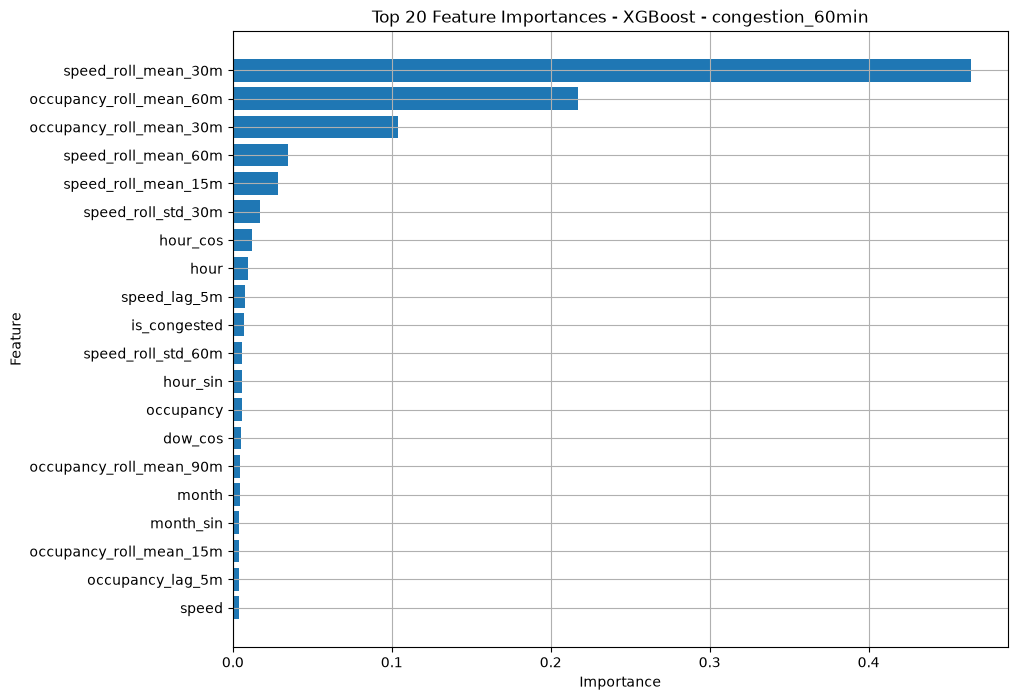

In [84]:
top_n = 20

top_features = importances.head(top_n).sort_values("importance")

plt.figure(figsize=(10, 8))
plt.barh(top_features["feature"], top_features["importance"])
plt.title(f"Top {top_n} Feature Importances - XGBoost - {target}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(True)
plt.show()

In [85]:
OPERATIONAL_THRESHOLD = 0.30

df_alerts_xgb = test_df.copy()
df_alerts_xgb["timestamp"] = pd.to_datetime(df_alerts_xgb["timestamp"])

for target in target_cols:
    horizon = target.replace("congestion_", "")

    model = xgb_models[target]

    proba_col = f"xgb_proba_{horizon}"
    alert_col = f"xgb_alert_{horizon}"

    df_alerts_xgb[proba_col] = model.predict_proba(
        df_alerts_xgb[feature_cols]
    )[:, 1]

    df_alerts_xgb[alert_col] = (
        df_alerts_xgb[proba_col] >= OPERATIONAL_THRESHOLD
    ).astype(int)

df_alerts_xgb.head()

,flow,occupancy,speed,timestamp,sensor_index,sensor_id,date,is_congested,congestion_30min,congestion_60min,...,occupancy_diff_5m,occupancy_diff_15m,xgb_proba_30min,xgb_alert_30min,xgb_proba_60min,xgb_alert_60min,xgb_proba_90min,xgb_alert_90min,xgb_proba_120min,xgb_alert_120min
220644,95.0,0.0365,60.800000,2024-09-13 02:55:00,14698,819086,2024-09-13,0,0.0,0.0,...,0.0046,0.0071,0.000768,0,0.000830,0,0.000866,0,0.000640,0
220645,76.0,0.0304,70.300003,2024-09-13 02:55:00,14698,819086,2024-09-13,0,0.0,0.0,...,-0.0061,-0.0047,0.000629,0,0.000706,0,0.000738,0,0.000509,0
220646,103.0,0.0362,64.800000,2024-09-13 03:00:00,14698,819086,2024-09-13,0,0.0,0.0,...,0.0022,0.0058,0.000396,0,0.000750,0,0.001113,0,0.000861,0
220647,98.0,0.0340,69.099998,2024-09-13 03:00:00,14698,819086,2024-09-13,0,0.0,0.0,...,0.0017,-0.0025,0.000487,0,0.000758,0,0.001221,0,0.000842,0
220648,94.0,0.0323,62.400000,2024-09-13 03:00:00,14698,819086,2024-09-13,0,0.0,0.0,...,0.0019,0.0004,0.000606,0,0.000801,0,0.001309,0,0.000912,0


In [86]:
daily_test_summary = (
    df_alerts_xgb
    .groupby(df_alerts_xgb["timestamp"].dt.date)
    .agg(
        avg_speed=("speed", "mean"),
        min_speed=("speed", "min"),
        slow_rate_30=("speed", lambda x: (x < 30).mean()),
        n_rows=("speed", "count")
    )
    .reset_index(names="date")
)

daily_test_summary.sort_values("slow_rate_30", ascending=False).head(10)

,date,avg_speed,min_speed,slow_rate_30,n_rows
98,2024-12-20,40.622801,7.1,0.496528,864
91,2024-12-13,40.752662,7.4,0.490741,864
84,2024-12-06,41.915509,7.9,0.487269,864
92,2024-12-14,40.334838,7.0,0.484954,864
97,2024-12-19,41.021528,7.4,0.483796,864
93,2024-12-15,39.414699,6.9,0.481481,864
85,2024-12-07,40.987384,8.1,0.473380,864
99,2024-12-21,42.970139,7.4,0.467593,864
86,2024-12-08,41.044329,7.1,0.450231,864
94,2024-12-16,42.103935,7.4,0.445602,864


In [87]:
selected_day = pd.Timestamp(
    daily_test_summary
    .sort_values("slow_rate_30", ascending=False)
    .iloc[0]["date"]
)

day_alerts = df_alerts_xgb[
    (df_alerts_xgb["timestamp"] >= selected_day) &
    (df_alerts_xgb["timestamp"] < selected_day + pd.Timedelta(days=1))
].copy()

print(day_alerts.shape)

(864, 68)


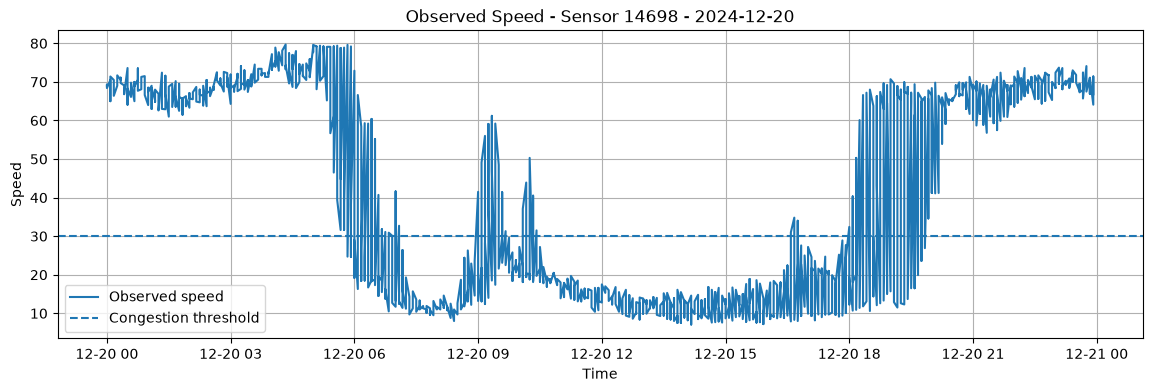

In [88]:
plt.figure(figsize=(14, 4))

plt.plot(day_alerts["timestamp"], day_alerts["speed"], label="Observed speed")
plt.axhline(30, linestyle="--", label="Congestion threshold")

plt.title(f"Observed Speed - Sensor {df['sensor_index'].iloc[0]} - {selected_day.date()}")
plt.xlabel("Time")
plt.ylabel("Speed")
plt.legend()
plt.grid(True)

plt.show()

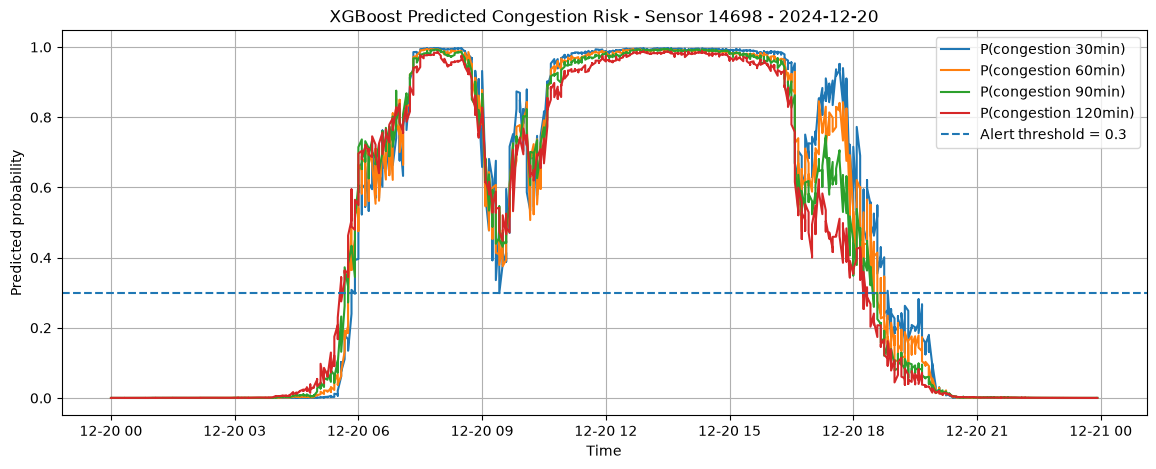

In [89]:
plt.figure(figsize=(14, 5))

plt.plot(day_alerts["timestamp"], day_alerts["xgb_proba_30min"], label="P(congestion 30min)")
plt.plot(day_alerts["timestamp"], day_alerts["xgb_proba_60min"], label="P(congestion 60min)")
plt.plot(day_alerts["timestamp"], day_alerts["xgb_proba_90min"], label="P(congestion 90min)")
plt.plot(day_alerts["timestamp"], day_alerts["xgb_proba_120min"], label="P(congestion 120min)")

plt.axhline(OPERATIONAL_THRESHOLD, linestyle="--", label=f"Alert threshold = {OPERATIONAL_THRESHOLD}")

plt.title(f"XGBoost Predicted Congestion Risk - Sensor {df['sensor_index'].iloc[0]} - {selected_day.date()}")
plt.xlabel("Time")
plt.ylabel("Predicted probability")
plt.legend()
plt.grid(True)

plt.show()

In [90]:
target = "congestion_60min"

model = xgb_models[target]

xgb_importances = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

xgb_importances.head(20)

,feature,importance
35,speed_roll_mean_30m,0.464402
42,occupancy_roll_mean_60m,0.217221
38,occupancy_roll_mean_30m,0.103667
39,speed_roll_mean_60m,0.034772
31,speed_roll_mean_15m,0.028622
36,speed_roll_std_30m,0.016981
10,hour_cos,0.012007
4,hour,0.009486
16,speed_lag_5m,0.007538
3,is_congested,0.007310


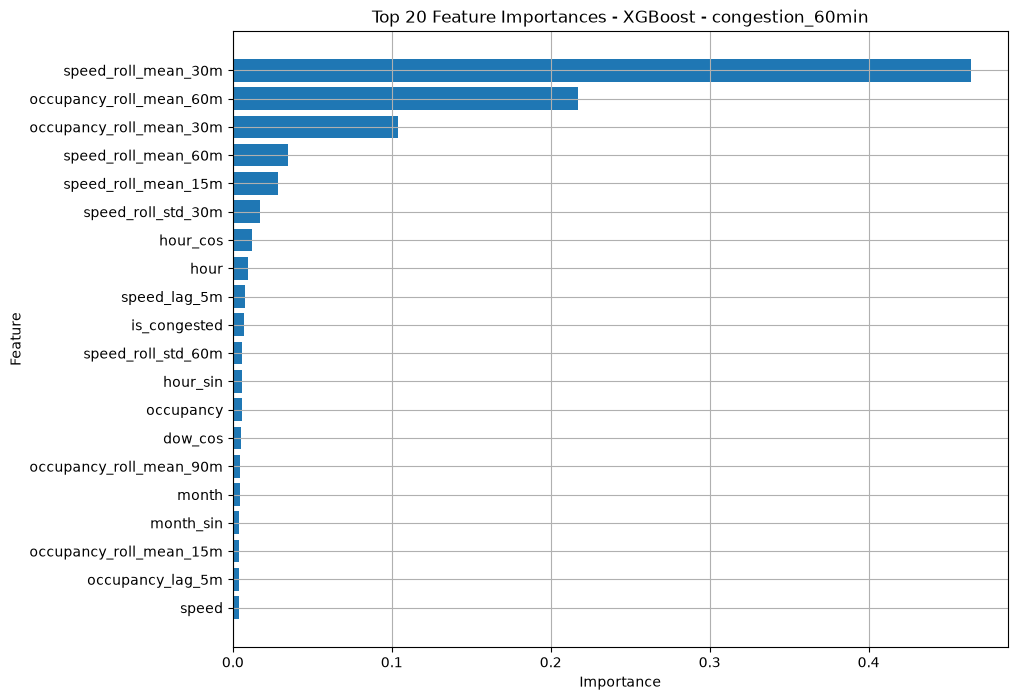

In [91]:
top_features = xgb_importances.head(20).sort_values("importance")

plt.figure(figsize=(10, 8))
plt.barh(top_features["feature"], top_features["importance"])

plt.title(f"Top 20 Feature Importances - XGBoost - {target}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(True)

plt.show()